# EXPORTACION

# Modificador de Spectral Cubes

In [1]:
from astropy.io import fits
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, brentq
from astropy.modeling.models import SmoothlyBrokenPowerLaw1D
from astropy.modeling.fitting import LevMarLSQFitter
import os
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']
import sys
import astropy.constants as const

sys.path.append('../../src')

DATA_DIR = '/Users/kuky/Documents/practica/Denoiser3D-IFU/data'

mkdir -p failed for path /.matplotlib: [Errno 30] Read-only file system: '/.matplotlib'
Matplotlib created a temporary cache directory at /var/folders/2b/5tqr_dzn551f21glw27fr5t40000gn/T/matplotlib-blur73cf because there was an issue with the default path (/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


In [44]:
CUBE_TYPE_DIR = 'real_cubes'
CUBE_DIR = 'condor06ld'
CUBE_NAME = 'CONDOR06LD_spw27_18kms_r05_subcube1'

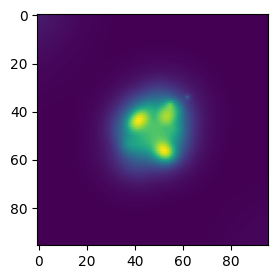

In [47]:
hdu = fits.open(os.path.join(DATA_DIR,CUBE_TYPE_DIR,CUBE_DIR,f'{CUBE_NAME}_wavelets_iterative_soft_5.fits'))
cube = np.squeeze(hdu[0].data)
cube = np.nan_to_num(cube, nan=0.0) # Se reemplazan los NaN por 0

plt.figure(figsize=(3, 3))
plt.imshow(np.sum(cube, axis=0))

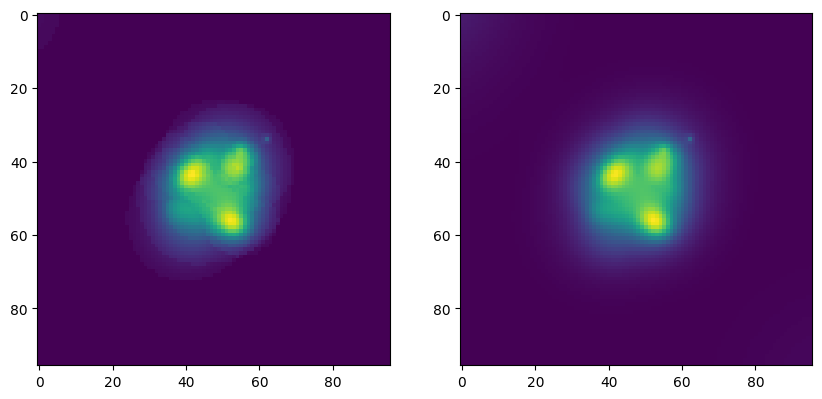

In [52]:
cube_mask = cube > (1.48e-4 / 2)
cube_masked = np.where(cube_mask, cube, np.nan)

fig, axs = plt.subplots(1,2, figsize=(10, 5))
axs[0].imshow(np.nansum(cube_masked, axis=0))
axs[1].imshow(np.sum(cube, axis=0))


In [53]:
# Define qué quieres guardar (ceros o NaN fuera de la máscara)
cube_masked = np.where(cube_mask, cube, np.nan)   # o np.nan si prefieres marcar lo enmascarado

# Reutiliza la cabecera del HDU original para conservar WCS/unidades
header = hdu[0].header

out_path = os.path.join(DATA_DIR, CUBE_TYPE_DIR, CUBE_DIR, f'{CUBE_NAME}_masked_half_knee.fits')
cube_to_save = cube_masked.reshape(hdu[0].data.shape)
fits.writeto(out_path, cube_to_save.astype(np.float32), header=header, overwrite=True)